# Dataset Explore `10-31-2025`

In [37]:
!pip install matplotlib -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [5]:
from datasets import load_dataset
from tqdm.notebook import tqdm
from transformers import AutoTokenizer

In [6]:
model_name = "deepseek-ai/deepseek-coder-1.3b-instruct"
# model_name = "meta-llama/Llama-2-7b-hf"

# model = AutoModelForCausalLM.from_pretrained(model_name,
#                                             #  torch_dtype=torch.float16
#                                              )
tokenizer = AutoTokenizer.from_pretrained(model_name,
                                          # torch_dtype=torch.float16
                                          )

In [24]:
# dataset = load_dataset('json', data_files='PyranetStatisticData/dataset_all_with_cell_num_error_timeout.jsonl', split = "train")
dataset = load_dataset('bnadimi/PyraNet-Verilog', split = "train")

In [ ]:
dataset.to_json('bnadimi_PyraNet-fixed_code_only.jsonl')

In [93]:
dataset

Dataset({
    features: ['code', 'description', 'token_length'],
    num_rows: 692238
})

In [94]:
dataset['code'][433772]

"module CAM (\n    input wire clk,\n    input wire reset,\n    input wire [7:0] data_in,        // Data input for write operation\n    input wire [7:0] search_data,     // Data input for search operation\n    input wire write_enable,          // Write enable signal\n    input wire search_enable,         // Search enable signal\n    output reg [7:0] match_data,      // Matched data output\n    output reg match_found,           // Match found signal\n    output reg [7:0] match_address     // Address of the first match\n);\n\n    parameter NUM_ENTRIES = 256;      // Number of entries in the CAM\n    reg [7:0] memory [0:NUM_ENTRIES-1]; // Memory array\n\n    integer i;\n\n    // Initialize memory on reset\n    always @(posedge clk or posedge reset) begin\n        if (reset) begin\n            for (i = 0; i < NUM_ENTRIES; i = i + 1) begin\n                memory[i] <= 8'b0; // Clear memory\n            end\n            match_found <= 0;\n            match_address <= 8'b0;\n        end else 

In [10]:
from module_extraction import module_extraction
failed_code = set()
# for i in range(len(dataset)):
def do_process(i):
    code = dataset['code'][i]
    code = code.replace("\\\\", "\\")

    try:
        module_extraction(code)
        # print(None)
        return None
    except:
        # print(i)
        # pass
        # break
        return i

In [11]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool
from tqdm.notebook import tqdm
import os

num_core = os.cpu_count() - 4
my_range = range(len(dataset))

# synth_error_ex = set()
# synth_timeout_ex = set()
# all_total_num_cells = [None] * (len(my_range))
with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        if i != None:
            failed_code.add(i)

  0%|          | 0/692238 [00:00<?, ?it/s]

In [12]:
len(failed_code)

256233

In [13]:
filder_index = [i for i in range(len(dataset)) if i not in failed_code]
len(filder_index)

436005

In [14]:
dataset = dataset.select(filder_index)
dataset

Dataset({
    features: ['code', 'description'],
    num_rows: 436005
})

In [26]:
import json, re, tempfile, subprocess, os
import numpy as np
from module_extraction import module_extraction

def formatting_prompts_func(examples):
    descriptions = examples["description"]
    
    codes = examples["code"]
    # chats = []
    # texts = []
    # systems = []
    # instructions = []
    # outputs = []
    token_lengths = []
    # seq_lengths = []
    for description, code in zip(descriptions, codes):
        # Must add EOS_TOKEN, otherwise your generation will go on forever!
        description = description.replace("\\\\", "\\")
        description = json.loads(description)['description']
        code = code.replace("\\\\", "\\")

        # try:
        #     _, _, _, module_def_span, _ = module_extraction(code)
        #     module_defs = "\n".join([code[span[0]:span[2]] for span in module_def_span])
        # except:
        #     module_defs = ""
        
#         instruction = "You are an AI programming assistant, utilizing the DeepSeek Coder model, developed by DeepSeek Company, and you only answer questions related to computer science. For politically sensitive questions, security and privacy issues, and other non-computer science questions, you will refuse to answer."
#         iinput = description + """
# You generate the required Verilog code only.
# The Verilog code must contain one of keywords performing logic operations, such as \"always\", \"and\", \"assign\", \"not\", \"nand\", \"nor\", \"or\", \"xnor\", \"xor\", or \"display\".
# Further explanation must be construct as the syntax of Verilog comment.""" + "\n"*2 + module_defs
#         output = code
#         chat = [
#             {"role": "system", "content": instruction},
#             {"role": "user", "content": iinput},
#             {"role": "assistant", "content": output}]
#         text = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False) #+ tokenizer.eos_token
        seq = description+code
        tokenized_seq = tokenizer(seq, return_tensors="pt")
        
        # token_lengths.append(seq["input_ids"].shape[1])
        # text = tokenizer.tokenize(seq)
        token_lengths.append(tokenized_seq["input_ids"].shape[1])
        # seq_lengths.append(len(seq))
        # texts.append(re.sub(r'\n\n+', '\n', text))
    return { 
        # "text" : texts,
        "token_length": token_lengths,
        # "seq_length": seq_lengths,
    }

In [27]:
dataset = dataset.map(formatting_prompts_func, batched = True, num_proc=os.cpu_count())

Map (num_proc=112):   0%|          | 0/692238 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (19268 > 16384). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (21928 > 16384). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (19187 > 16384). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (20240 > 16384). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (19063 > 16384). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum seq

In [28]:
print(np.max(dataset['token_length']))

81441


In [29]:
dataset['token_length'] == 19400

False

## Count # of token

In [33]:
import glob

all_num_cell_file = glob.glob(".cache_count_num_cell_2/*")

In [34]:
all_num_cell_file

['.cache_count_num_cell_2/75.txt',
 '.cache_count_num_cell_2/84.txt',
 '.cache_count_num_cell_2/78.txt',
 '.cache_count_num_cell_2/80.txt',
 '.cache_count_num_cell_2/76.txt',
 '.cache_count_num_cell_2/82.txt',
 '.cache_count_num_cell_2/77.txt',
 '.cache_count_num_cell_2/86.txt',
 '.cache_count_num_cell_2/93.txt',
 '.cache_count_num_cell_2/95.txt',
 '.cache_count_num_cell_2/87.txt',
 '.cache_count_num_cell_2/94.txt',
 '.cache_count_num_cell_2/83.txt',
 '.cache_count_num_cell_2/89.txt',
 '.cache_count_num_cell_2/85.txt',
 '.cache_count_num_cell_2/90.txt',
 '.cache_count_num_cell_2/81.txt',
 '.cache_count_num_cell_2/91.txt',
 '.cache_count_num_cell_2/96.txt',
 '.cache_count_num_cell_2/88.txt',
 '.cache_count_num_cell_2/98.txt',
 '.cache_count_num_cell_2/97.txt',
 '.cache_count_num_cell_2/99.txt',
 '.cache_count_num_cell_2/92.txt',
 '.cache_count_num_cell_2/28.txt',
 '.cache_count_num_cell_2/44.txt',
 '.cache_count_num_cell_2/43.txt',
 '.cache_count_num_cell_2/46.txt',
 '.cache_count_num_c

In [35]:
import numpy as np

all_cell_num_with_no_null = np.array([[None, None]] * len(dataset))
all_cell_num_with_no_null

array([[None, None],
       [None, None],
       [None, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(692238, 2), dtype=object)

In [36]:
import glob, os
from module_extraction import module_extraction
import subprocess, tempfile, json, signal, os

# for prompt_dir in all_prompt_dir:
# for i in range(len(all_num_cell_file)):
def do_process(i):
    filename_path = all_num_cell_file[i]
    file_name = os.path.basename(filename_path)
    logic_index = int(file_name.replace(".txt", ""))
    # print(file_name)
    with open(filename_path, 'r') as file:
        file_list = file.read().split(",")
        return (logic_index, tuple(file_list))
        # all_cell_num_with_no_null[logic_index][0] = int(file_list[0])
        # all_cell_num_with_no_null[logic_index][1] = int(file_list[1]) if file_list[1] != 'None' else None

In [37]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool
from tqdm.notebook import tqdm
import os

num_core = os.cpu_count() - 4
my_range = range(len(all_num_cell_file))

# synth_error_ex = set()
# synth_timeout_ex = set()
# all_total_num_cells = [None] * (len(my_range))
with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        logic_index, file_list = i
        all_cell_num_with_no_null[logic_index][0] = int(file_list[0])
        all_cell_num_with_no_null[logic_index][1] = int(file_list[1]) if file_list[1] != 'None' else None

  0%|          | 0/692238 [00:00<?, ?it/s]

In [38]:
all_cell_num_with_no_null

array([[0, 0],
       [0, 2],
       [0, 1],
       ...,
       [0, None],
       [0, None],
       [0, None]], shape=(692238, 2), dtype=object)

In [39]:
all_cell_num_with_no_null = all_cell_num_with_no_null[:,1]
all_cell_num_with_no_null

array([0, 2, 1, ..., None, None, None], shape=(692238,), dtype=object)

In [40]:
np.where(all_cell_num_with_no_null != None)

(array([     0,      1,      2, ..., 680123, 681657, 688153],
       shape=(327529,)),)

In [41]:
import numpy as np
all_cell_num_with_no_null = np.column_stack((all_cell_num_with_no_null, range(len(dataset))))


In [42]:
all_cell_num_null_idx = np.where(all_cell_num_with_no_null[:, 0] != None)
all_cell_num_null_idx

(array([     0,      1,      2, ..., 680123, 681657, 688153],
       shape=(327529,)),)

In [43]:
dataset_filter = dataset.select(all_cell_num_null_idx[0])
dataset_filter

Dataset({
    features: ['code', 'description', 'token_length'],
    num_rows: 327529
})

In [44]:
all_cell_num_with_no_null = all_cell_num_with_no_null[all_cell_num_null_idx].astype(np.uint64)
all_cell_num_with_no_null

array([[     0,      0],
       [     2,      1],
       [     1,      2],
       ...,
       [    31, 680123],
       [    78, 681657],
       [    12, 688153]], shape=(327529, 2), dtype=uint64)

In [45]:
all_cell_num_with_no_null = np.column_stack((all_cell_num_with_no_null.astype(object), [''] * len(all_cell_num_with_no_null)))
all_cell_num_with_no_null

array([[0, 0, ''],
       [2, 1, ''],
       [1, 2, ''],
       ...,
       [31, 680123, ''],
       [78, 681657, ''],
       [12, 688153, '']], shape=(327529, 3), dtype=object)

In [46]:
max_cell = np.max(all_cell_num_with_no_null[:,0])
max_cell_idxs = np.where(all_cell_num_with_no_null[:,0] == max_cell)[0]
all_cell_num_with_no_null[max_cell_idxs]

array([[1052421, 433772, '']], dtype=object)

In [51]:
for i in range(len(all_cell_num_with_no_null)):
    int_x = all_cell_num_with_no_null[i][0]
    if int_x == 0:
        all_cell_num_with_no_null[i][2] = '0-0'
    else:
        # 1-100, 
        # 101-1000
        # 1001-10000
        # 10001-100000
        # 100001-25000

        start_i = 100001
        stop_i = 1100000
        step_i = 100000
        for ii in range(start_i,stop_i, step_i):
            cur_range = (ii, ii + step_i - 1)
            if cur_range[0] <= int_x <= cur_range[1]:
                all_cell_num_with_no_null[i][2] = f'{cur_range[0]}-{cur_range[1]}'
                break
all_cell_num_with_no_null

array([[0, 0, '0-0'],
       [2, 1, '1-10'],
       [1, 2, '1-10'],
       ...,
       [31, 680123, '31-40'],
       [78, 681657, '71-80'],
       [12, 688153, '11-20']], shape=(327529, 3), dtype=object)

In [52]:
np.unique(all_cell_num_with_no_null[:, 2])

array(['0-0', '1-10', '1000001-1100000', '100001-200000', '10001-20000',
       '1001-2000', '101-200', '11-20', '200001-300000', '20001-30000',
       '2001-3000', '201-300', '21-30', '300001-400000', '30001-40000',
       '3001-4000', '301-400', '31-40', '400001-500000', '40001-50000',
       '4001-5000', '401-500', '41-50', '500001-600000', '50001-60000',
       '5001-6000', '501-600', '51-60', '600001-700000', '60001-70000',
       '6001-7000', '601-700', '61-70', '70001-80000', '7001-8000',
       '701-800', '71-80', '800001-900000', '80001-90000', '8001-9000',
       '801-900', '81-90', '90001-100000', '9001-10000', '901-1000',
       '91-100'], dtype=object)

In [53]:
np.where(all_cell_num_with_no_null[:, 2] == '')

(array([], dtype=int64),)

In [54]:
# all_cell_num_with_no_null = np.column_stack((all_cell_num_with_no_null, [None] * len(all_cell_num_with_no_null), [None] * len(all_cell_num_with_no_null)))

In [55]:
print(dataset['description'][433772])

{"description": "", "rank": "-1", "complexity": "Intermediate", "compile_status": "Dependency issues!", "compile_results": "singleCheck.v:33: error: Enable of unknown task ``break''.\\nsingleCheck.v:46: error: Enable of unknown task ``break''.\\n2 error(s) during elaboration.\\n"}


In [56]:
print(dataset['code'][433772])

module CAM (
    input wire clk,
    input wire reset,
    input wire [7:0] data_in,        // Data input for write operation
    input wire [7:0] search_data,     // Data input for search operation
    input wire write_enable,          // Write enable signal
    input wire search_enable,         // Search enable signal
    output reg [7:0] match_data,      // Matched data output
    output reg match_found,           // Match found signal
    output reg [7:0] match_address     // Address of the first match
);

    parameter NUM_ENTRIES = 256;      // Number of entries in the CAM
    reg [7:0] memory [0:NUM_ENTRIES-1]; // Memory array

    integer i;

    // Initialize memory on reset
    always @(posedge clk or posedge reset) begin
        if (reset) begin
            for (i = 0; i < NUM_ENTRIES; i = i + 1) begin
                memory[i] <= 8'b0; // Clear memory
            end
            match_found <= 0;
            match_address <= 8'b0;
        end else begin
            // Write

In [57]:
# all_cell_num_with_no_null = np.delete(all_cell_num_with_no_null, np.s_[6:], 1)
all_cell_num_with_no_null = np.column_stack((all_cell_num_with_no_null, dataset_filter['token_length']))
all_cell_num_with_no_null

array([[0, 0, '0-0', 56],
       [2, 1, '1-10', 151],
       [1, 2, '1-10', 113],
       ...,
       [31, 680123, '31-40', 593],
       [78, 681657, '71-80', 1796],
       [12, 688153, '11-20', 423]], shape=(327529, 4), dtype=object)

In [58]:
cell_num_indexes, indices = np.unique(all_cell_num_with_no_null[:,0], return_index=True)
tuples_np = [all_cell_num_with_no_null[indices, 2], cell_num_indexes]
tuples_np

[array(['0-0', '1-10', '1-10', ..., '600001-700000', '800001-900000',
        '1000001-1100000'], shape=(4337,), dtype=object),
 array([0, 1, 2, ..., 662794, 880771, 1052421], shape=(4337,), dtype=object)]

In [59]:
import pandas as pd
tuples = list(zip(*[tuples_np[0].tolist(), tuples_np[1].tolist()]))
tuples

[('0-0', 0),
 ('1-10', 1),
 ('1-10', 2),
 ('1-10', 3),
 ('1-10', 4),
 ('1-10', 5),
 ('1-10', 6),
 ('1-10', 7),
 ('1-10', 8),
 ('1-10', 9),
 ('1-10', 10),
 ('11-20', 11),
 ('11-20', 12),
 ('11-20', 13),
 ('11-20', 14),
 ('11-20', 15),
 ('11-20', 16),
 ('11-20', 17),
 ('11-20', 18),
 ('11-20', 19),
 ('11-20', 20),
 ('21-30', 21),
 ('21-30', 22),
 ('21-30', 23),
 ('21-30', 24),
 ('21-30', 25),
 ('21-30', 26),
 ('21-30', 27),
 ('21-30', 28),
 ('21-30', 29),
 ('21-30', 30),
 ('31-40', 31),
 ('31-40', 32),
 ('31-40', 33),
 ('31-40', 34),
 ('31-40', 35),
 ('31-40', 36),
 ('31-40', 37),
 ('31-40', 38),
 ('31-40', 39),
 ('31-40', 40),
 ('41-50', 41),
 ('41-50', 42),
 ('41-50', 43),
 ('41-50', 44),
 ('41-50', 45),
 ('41-50', 46),
 ('41-50', 47),
 ('41-50', 48),
 ('41-50', 49),
 ('41-50', 50),
 ('51-60', 51),
 ('51-60', 52),
 ('51-60', 53),
 ('51-60', 54),
 ('51-60', 55),
 ('51-60', 56),
 ('51-60', 57),
 ('51-60', 58),
 ('51-60', 59),
 ('51-60', 60),
 ('61-70', 61),
 ('61-70', 62),
 ('61-70', 63)

In [60]:
multi_index = pd.MultiIndex.from_tuples(tuples, names=["# of Cells", "second"])
multi_index

MultiIndex([(            '0-0',       0),
            (           '1-10',       1),
            (           '1-10',       2),
            (           '1-10',       3),
            (           '1-10',       4),
            (           '1-10',       5),
            (           '1-10',       6),
            (           '1-10',       7),
            (           '1-10',       8),
            (           '1-10',       9),
            ...
            (  '500001-600000',  526346),
            (  '500001-600000',  526352),
            (  '500001-600000',  526363),
            (  '500001-600000',  526613),
            (  '500001-600000',  530186),
            (  '500001-600000',  543921),
            (  '600001-700000',  658461),
            (  '600001-700000',  662794),
            (  '800001-900000',  880771),
            ('1000001-1100000', 1052421)],
           names=['# of Cells', 'second'], length=4337)

In [61]:
df_item_indexes = [np.where(all_cell_num_with_no_null[:, 0] == i) for i in tuples_np[1]]

In [62]:
df_item_indexes

[(array([     0,      3,     59, ..., 327507, 327514, 327523],
        shape=(24515,)),),
 (array([     2,      4,      6, ..., 327484, 327510, 327517],
        shape=(22196,)),),
 (array([     1,      5,     14, ..., 327480, 327503, 327519],
        shape=(26474,)),),
 (array([    19,     20,     81, ..., 320272, 320273, 324077],
        shape=(16966,)),),
 (array([   230,    414,    415, ..., 321916, 327448, 327493],
        shape=(14628,)),),
 (array([   429,    432,    444, ..., 326742, 326743, 327499],
        shape=(14877,)),),
 (array([   474,    476,    560, ..., 327109, 327110, 327112],
        shape=(11596,)),),
 (array([   275,    276,    277, ..., 327113, 327454, 327462],
        shape=(12709,)),),
 (array([   631,    966,   1030, ..., 327509, 327512, 327515], shape=(9398,)),),
 (array([   426,    694,    840, ..., 327384, 327391, 327446], shape=(7825,)),),
 (array([   633,    897,    983, ..., 327377, 327382, 327501], shape=(6493,)),),
 (array([   217,    537,   1010, ...,

In [63]:
df_array = [[len(i[0]), np.sum(all_cell_num_with_no_null[i[0], 3])] for i in df_item_indexes]
df_array

[[24515, 12571643],
 [22196, 5099006],
 [26474, 10482008],
 [16966, 5660712],
 [14628, 6181979],
 [14877, 6055101],
 [11596, 4590349],
 [12709, 4879177],
 [9398, 4154431],
 [7825, 3512450],
 [6493, 3208357],
 [5488, 2615158],
 [5674, 3072444],
 [3918, 2135569],
 [4156, 2361329],
 [3904, 2144137],
 [3944, 2576403],
 [3323, 2079685],
 [3287, 2007638],
 [2978, 1951745],
 [3494, 2144141],
 [2635, 1807930],
 [2569, 1769450],
 [2320, 1604577],
 [3011, 2084078],
 [2077, 1581892],
 [2173, 1645125],
 [2104, 1766353],
 [2730, 1966137],
 [1912, 1470745],
 [1977, 1603575],
 [1859, 1535546],
 [2497, 1987642],
 [1892, 1752284],
 [1616, 1412360],
 [1550, 1267748],
 [1720, 1476993],
 [1376, 1278453],
 [1292, 1232180],
 [1265, 1185298],
 [1572, 1332234],
 [1208, 1171126],
 [1264, 1323388],
 [1118, 1088009],
 [1260, 1135588],
 [1047, 988237],
 [1117, 1154897],
 [1159, 1069138],
 [1338, 1252184],
 [1005, 1136091],
 [1021, 1121607],
 [981, 944954],
 [1058, 1076141],
 [905, 982585],
 [979, 1195474],
 [852,

In [64]:
my_df = pd.DataFrame(df_array, index=multi_index, columns=["# of Modules", "# of Tokens"])
my_df

# of Modules  # of Tokens
# of Cells      second                            
0-0             0               24515     12571643
1-10            1               22196      5099006
                2               26474     10482008
                3               16966      5660712
                4               14628      6181979
...                               ...          ...
500001-600000   543921              1         6914
600001-700000   658461              1          570
                662794              1          787
800001-900000   880771              1          314
1000001-1100000 1052421             1          515

[4337 rows x 2 columns]

In [65]:
my_df_group = my_df.groupby(level=0).sum()
my_df_group

,# of Modules,# of Tokens
# of Cells,,
0-0,24515,12571643
1-10,143162,53823570
1000001-1100000,1,515
100001-200000,75,149843
10001-20000,470,1401767
1001-2000,2407,13465840
101-200,17030,35518326
11-20,40166,23088249
200001-300000,12,36109


In [66]:
my_df_group = my_df_group.sort_index(key=lambda x: x.str.split('-').map(lambda y: int(y[0])))
my_df_group

,# of Modules,# of Tokens
# of Cells,,
0-0,24515,12571643
1-10,143162,53823570
11-20,40166,23088249
21-30,23508,17299862
31-40,16639,14460738
41-50,11537,11440265
51-60,8750,9771388
61-70,6557,8629493
71-80,5181,6968330


In [67]:
dataset

Dataset({
    features: ['code', 'description', 'token_length'],
    num_rows: 692238
})

In [68]:
reindexes = []
for index in my_df_group.loc['100001-200000':].index:
    x0, x1 = [int(x) for x in index.split('-')]
    reindexes.append('1+{:.0e}-{:.0e}'.format(x0-1, x1))
print(my_df_group.loc['100001-200000':].index.reindex(reindexes))
# my_df_group

(Index(['1+1e+05-2e+05', '1+2e+05-3e+05', '1+3e+05-4e+05', '1+4e+05-5e+05',
       '1+5e+05-6e+05', '1+6e+05-7e+05', '1+8e+05-9e+05', '1+1e+06-1e+06'],
      dtype='object', name='# of Cells'), array([-1, -1, -1, -1, -1, -1, -1, -1]))


<function print>

In [70]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pandas.plotting import table

plt_subplot_mosaic = [[0, 0],
                     [1,2],
                     [3,4]]
plt.figure()
# fig, axd = plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')
fig = plt.figure(figsize=(10, 10))

df_ranges = [('0-0', '91-100'), 
             ('101-200', '901-1000'), 
             ('1001-2000', '9001-10000'),
             ('10001-20000', '90001-100000'),
             ('100001-200000', None),
            ]
with PdfPages('PyranetStatisticData/all_plot_final_6.pdf') as pdf:
    # https://stackoverflow.com/questions/75357468/matplotlib-supylabel-on-second-axis-of-multiplot
    # dummy axes 1
    ax = fig.add_subplot(1, 1, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    [ax.spines[side].set_visible(False) for side in ('left', 'top', 'right', 'bottom')]
    ax.patch.set_visible(False)
    ax.set_xlabel('# of Cells', labelpad=70)
    ax.set_ylabel('# of Modules', labelpad=50)
    
    # dummy axes 2 for right ylabel
    ax = fig.add_subplot(1, 1, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    [ax.spines[side].set_visible(False) for side in ('left', 'top', 'right', 'bottom')]
    ax.patch.set_visible(False)
    ax.yaxis.set_label_position('right')
    ax.set_ylabel('# of Tokens', labelpad=50, rotation=270)

    num_rows = len(plt_subplot_mosaic)
    subplot_index = 0
    for i in range(len(df_ranges)):
        df_range = df_ranges[i]
        df_plot: pd.DataFrame = my_df_group.loc[df_range[0]:df_range[1]]
        df_plot = df_plot.astype(np.uint64)
        #
        
        rot = 22.5
        if i == len(df_ranges) - 1:
            rot = 31
            # reindexes = []
            # for index in my_df_group.loc['100001-200000':].index:
            #     x0, x1 = [int(x) for x in index.split('-')]
            #     reindexes.append('1+{:.0e}-{:.0e}'.format(x0-1, x1))
            # df_plot.index = my_df_group.loc['100001-200000':].index.reindex(reindexes)[0]
        num_cols = 2 if i > 0 else 1
        ax = fig.add_subplot(num_rows, num_cols, subplot_index + 1)
        # ax.get_xaxis().set_visible(False)
        subplot_index += 1 if i > 0 else 2
        
        # colWidths = [1/4, 1/4] if i == 0 else [1/2, 1/2]
        # df_plot["# of Tokens"].plot.line(rot=rot, ax=ax, figsize=(10, 10), secondary_y=["# of Tokens"], color='red', legend=True)
        # df_plot["# of Modules"].plot.bar(rot=rot, ax=ax, figsize=(10, 10), legend=True)
        bar_container = ax.bar(df_plot["# of Modules"].index, df_plot["# of Modules"], label='# of Modules')
        ax.tick_params(axis='x', labelrotation=rot)

        ax_twin = ax.twinx()
        line_2d = ax_twin.plot(df_plot["# of Tokens"].index, df_plot["# of Tokens"], label='# of Tokens', color='red')
        # print(line_2d)
        # ax.legend()
        # ax.set_xlabel('')
        # ax.legend()
        df_plot_total = pd.DataFrame(df_plot.sum()).T.rename(index={0: 'total'})#, columns={0: 'Number of Modules'})
        # break
        df_plot_statistic = df_plot.describe().loc[['min', 'max']]
        
        df_plot_statistic = pd.concat([df_plot_statistic, df_plot_total]).astype(np.uint64)
        colWidths = [1/5, 1/5] if i == 0 else [1/3, 1/3]
        cur_table = table(ax, df_plot_statistic, loc="upper right", colWidths=colWidths)
        
            # print(ax.secondary_yaxis.legend)
        if i == 0:
            # print(ax.lines)
            ax.legend(handles=[bar_container, line_2d[0]], bbox_to_anchor=(0., 1.02, .38, .152), loc='best',
                      ncols=2, mode="expand", borderaxespad=0.)
    fig.tight_layout()
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory
# 

<Figure size 640x480 with 0 Axes>

## Count # of Token of Timeout modules

In [41]:
synth_status_idx = np.array(dataset['synth_status'])
synth_status_idx

array([None, None, None, ..., 1.0, 1.0, 1.0],
      shape=(661318,), dtype=object)

In [43]:
synth_timeout_status_idx = np.where(synth_status_idx == 2)
synth_timeout_status_idx

(array([  1188,   1284,   4577, ..., 654219, 656237, 659494], shape=(1061,)),)

In [45]:
import json
from tqdm.notebook import tqdm
def count_token(i, ii):
# for i in tqdm(range(len(all_cell_num_with_no_null))):

    # ii = all_cell_num_with_no_null[i][1]
    
    example_description = dataset['description'][ii]
    example_description = example_description.replace("\\\\", "\\")
    example_description_dict = json.loads(example_description)
    example_description = example_description_dict['description']
    example_code = dataset["code"][ii]
    example_code = example_code.replace("\\\\", "\\")

    return (len(example_description), len(example_code))

In [49]:
synth_timeout_status_idx

(array([  1188,   1284,   4577, ..., 654219, 656237, 659494], shape=(1061,)),)

In [53]:
total_token = 0
for i in tqdm(synth_timeout_status_idx[0]):
    total_token += sum(count_token(i, i))
    # print(i)
    # break
total_token

  0%|          | 0/1061 [00:00<?, ?it/s]

4940615

In [54]:
synth_error_status_idx = np.where(synth_status_idx == 1)
synth_error_status_idx

(array([    23,     45,     52, ..., 661315, 661316, 661317],
       shape=(305429,)),)

In [55]:
total_token = 0
for i in tqdm(synth_error_status_idx[0]):
    total_token += sum(count_token(i, i))
    # print(i)
    # break
'{:.0e}'.format(total_token)

  0%|          | 0/305429 [00:00<?, ?it/s]

'1e+09'

## Compare with old indexes

In [56]:
old_training_idxs = np.load("TrainDataset/train_index1.npy")
old_training_idxs

array([     0,      1,      2, ..., 354823, 354826, 354827],
      shape=(233720,))

In [121]:
all_cell_num_with_no_null_0_100 = all_cell_num_with_no_null[:, 0:2]
all_cell_num_with_no_null_0_100

array([[0, 0],
       [2, 1],
       [1, 2],
       ...,
       [31, 680123],
       [78, 681657],
       [12, 688153]], shape=(327529, 2), dtype=object)

In [122]:
all_cell_num_with_no_null_0_100 = np.column_stack((all_cell_num_with_no_null_0_100, [None] * len(all_cell_num_with_no_null_0_100)))
all_cell_num_with_no_null_0_100

array([[0, 0, None],
       [2, 1, None],
       [1, 2, None],
       ...,
       [31, 680123, None],
       [78, 681657, None],
       [12, 688153, None]], shape=(327529, 3), dtype=object)

In [123]:
# 1-100, 
# 101-1000
# 1001-10000
# 10001-100000
# 100001-25000

start_i = 100001
stop_i = 1100000
step_i = 100000
for i in range(len(all_cell_num_with_no_null_0_100)):
    int_x = all_cell_num_with_no_null_0_100[i][0]
    if int_x == 0:
        # all_cell_num_with_no_null_0_100[i][2] = '0-0'
        pass
    else:
        for ii in range(start_i,stop_i, step_i):
            cur_range = (ii, ii + step_i - 1)
            if cur_range[0] <= int_x <= cur_range[1]:
                all_cell_num_with_no_null_0_100[i][2] = f'{cur_range[0]}-{cur_range[1]}'
                break
all_cell_num_with_no_null_0_100

array([[0, 0, None],
       [2, 1, None],
       [1, 2, None],
       ...,
       [31, 680123, None],
       [78, 681657, None],
       [12, 688153, None]], shape=(327529, 3), dtype=object)

In [124]:
filter_idxs = np.where(all_cell_num_with_no_null_0_100[:, 2] != None)[0]
filter_idxs

array([  1194,  49940,  63875,  65135,  68403,  76582, 109627, 117564,
       120412, 121565, 125065, 128513, 129690, 135038, 137443, 143508,
       145048, 145055, 147383, 147478, 151404, 152035, 152327, 154557,
       155620, 155726, 156335, 159375, 160521, 165022, 169846, 169879,
       175291, 177248, 180364, 180776, 182094, 182247, 182250, 185990,
       186306, 188396, 193454, 198193, 203063, 208527, 213572, 214567,
       218054, 222562, 224848, 226681, 226871, 240232, 243806, 245238,
       248286, 252084, 253687, 254594, 255721, 257015, 259836, 260728,
       266571, 270491, 272617, 274625, 296864, 296879, 300908, 303675,
       304162, 320537, 320736, 320929, 321048, 321065, 321067, 321069,
       321071, 321080, 321082, 321128, 321160, 321161, 321162, 322852,
       323353, 324207, 324213, 325233, 325235, 325236, 325253, 325254,
       325256, 325263, 325264, 325281, 325284, 325287, 325288, 325289,
       325292, 325294, 325523, 325855, 326284, 326428, 327134, 327135,
      

In [125]:
# old_training_idxs
setdiff1d_of2 = np.setdiff1d(filter_idxs, old_training_idxs, assume_unique=True)
# setdiff1d_of2 = [x for x in setdiff1d_of2 if x in filter_idxs]
len(setdiff1d_of2)

43

In [134]:
np.save(f"TrainDataset/train_index2_{start_i}_{stop_i}.npy", setdiff1d_of2)

In [135]:
training_idxs = glob.glob('TrainDataset/train_index2*')
total_idxs = 0
for training_idx in training_idxs:
    idx_len = len(np.load(training_idx))
    print(idx_len)
    total_idxs += idx_len
total_idxs

96499
12030
1677
402
43


110651

In [131]:
len(old_training_idxs) + total_idxs

344371

## Extract LoRa-256 Dataset

In [4]:
import numpy as np

all_cell_num = np.array(dataset['num_cell'])
all_cell_num

array([0.0, 2.0, 16.0, ..., None, None, None],
      shape=(661318,), dtype=object)

In [5]:
all_cell_num = np.column_stack((all_cell_num, range(len(dataset['num_cell']))))
all_cell_num

array([[0.0, 0],
       [2.0, 1],
       [16.0, 2],
       ...,
       [None, 661315],
       [None, 661316],
       [None, 661317]], shape=(661318, 2), dtype=object)

In [6]:
all_cell_num = np.column_stack((all_cell_num, [None] * len(dataset['num_cell'])))
all_cell_num

array([[0.0, 0, None],
       [2.0, 1, None],
       [16.0, 2, None],
       ...,
       [None, 661315, None],
       [None, 661316, None],
       [None, 661317, None]], shape=(661318, 3), dtype=object)

In [7]:
all_cell_num_no_none_idx = np.where(all_cell_num[:, 0] != None)
all_cell_num = all_cell_num[all_cell_num_no_none_idx]
all_cell_num

array([[0.0, 0, None],
       [2.0, 1, None],
       [16.0, 2, None],
       ...,
       [277.0, 661292, None],
       [3.0, 661309, None],
       [0.0, 661311, None]], shape=(354828, 3), dtype=object)

In [8]:
for i in range(len(all_cell_num)):
    int_x = all_cell_num[i][0]
    if int_x == 0:
        all_cell_num[i][2] = '0-0'
    else:
        # 1-100, 
        # 101-1000
        # 1001-10000
        # 10001-100000
        # 100001-25000

        start_i = 1
        stop_i = 100
        step_i = 10
        for ii in range(start_i,stop_i, step_i):
            cur_range = (ii, ii + step_i - 1)
            if cur_range[0] <= int_x <= cur_range[1]:
                all_cell_num[i][2] = f'{cur_range[0]}-{cur_range[1]}'
                break
all_cell_num

array([[0.0, 0, '0-0'],
       [2.0, 1, '1-10'],
       [16.0, 2, '11-20'],
       ...,
       [277.0, 661292, None],
       [3.0, 661309, '1-10'],
       [0.0, 661311, '0-0']], shape=(354828, 3), dtype=object)

In [9]:
all_range_no_none_idx = np.where(all_cell_num[:, 2] != None)
all_range_no_none_idx

(array([     0,      1,      2, ..., 354823, 354826, 354827],
       shape=(233720,)),)

In [10]:
dataset_select = dataset.select(all_cell_num[all_range_no_none_idx, 1][0])
dataset_select

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell'],
    num_rows: 233720
})

In [82]:
dataset_select = dataset_no_logic
dataset_select

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell'],
    num_rows: 217336
})

In [47]:
filter_set = set()

In [15]:
from transformers import AutoTokenizer
model_name="deepseek-ai/deepseek-coder-7b-instruct-v1.5"
tokenizer = AutoTokenizer.from_pretrained(model_name,
                                          # torch_dtype=torch.float16
                                          )

In [16]:
import json, re, tempfile, subprocess, os
import numpy as np

def formatting_prompts_func(examples):
    # instructions = examples["instruction"]
    # inputs       = examples["input"]
    # outputs      = examples["output"]
    descriptions = examples["description"]
    module_def_spans = examples["module_def_span"]
    codes = examples["code"]
    # chats = []
    # texts = []
    systems = []
    instructions = []
    outputs = []
    for description, module_def_span, code in zip(descriptions, module_def_spans, codes):
        # Must add EOS_TOKEN, otherwise your generation will go on forever!
        description = description.replace("\\\\", "\\")
        description = json.loads(description)['description']
        code = code.replace("\\\\", "\\")
        
        module_def_span = module_def_span
        module_defs = "\n".join([code[span[0]:span[2]] for span in module_def_span])
        
        instruction = "You are an AI programming assistant, utilizing the DeepSeek Coder model, developed by DeepSeek Company, and you only answer questions related to computer science. For politically sensitive questions, security and privacy issues, and other non-computer science questions, you will refuse to answer."
        iinput = description + """
You generate the required Verilog code only.
The Verilog code must contain one of keywords performing logic operations, such as \"always\", \"and\", \"assign\", \"not\", \"nand\", \"nor\", \"or\", \"xnor\", \"xor\", or \"display\".
Further explanation must be construct as the syntax of Verilog comment.""" + "\n"*2 + module_defs
        output = code
        # print(text)
        # chat = [
        #     {"role": "system", "content": instruction},
        #     {"role": "user", "content": iinput},
        #     {"role": "assistant", "content": output}]
        # text = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False) #+ tokenizer.eos_token
        # chats.append(chat)
        # texts.append((text.strip()).lstrip())
        # texts.append(re.sub(r'\n\n+', '\n', text))
        systems.append(instruction)
        instructions.append(iinput)
        outputs.append(output)
    # return { "text" : texts, }
    return {
        "system": systems,
        "instruction": instructions,
        "output": outputs
    }

# from datasets import load_dataset
# dataset = load_dataset("yahma/alpaca-cleaned", split = "train")
# dataset = dataset.map(formatting_prompts_func, batched = True,)

In [17]:
examples = {
    "description": [dataset_select['description'][100]],
    "module_def_span": [dataset_select['module_def_span'][100]],
    "code": [dataset_select['code'][100]],
}
_ = formatting_prompts_func(examples)

In [18]:
dataset_select = dataset_select.map(formatting_prompts_func, batched = True, num_proc=os.cpu_count())

Map (num_proc=24):   0%|          | 0/233876 [00:00<?, ? examples/s]

In [19]:
dataset_select

Dataset({
    features: ['description', 'code', 'module_def_span', 'system', 'instruction', 'output'],
    num_rows: 233876
})

In [120]:
print(dataset_select['text'][-141])

<｜begin▁of▁sentence｜>You are an AI programming assistant, utilizing the DeepSeek Coder model, developed by DeepSeek Company, and you only answer questions related to computer science. For politically sensitive questions, security and privacy issues, and other non-computer science questions, you will refuse to answer.### Instruction:
I would like you to implement a module named TopModule with the following
interface. All input and output ports are one bit unless otherwise
specified.
 - input  x   (4 bits)
 - input  y   (4 bits)
 - output sum (5 bits)
Implement a 4-bit adder with full adders. The output sum should include
the overflow bit.
You generate the required Verilog code only.
The Verilog code must contain one of keywords performing logic operations, such as "always", "and", "assign", "not", "nand", "nor", "or", "xnor", "xor", or "display".
Further explanation must be construct as the syntax of Verilog comment.
module RefModule (
  input [3:0] x,
  input [3:0] y,
  output [4:0] su

In [86]:
dataset_select = dataset_select.select(range(233720))
dataset_select

Dataset({
    features: ['description', 'code', 'module_def_span', 'text'],
    num_rows: 233720
})

In [121]:
print(dataset_select['text'][-156])

<｜begin▁of▁sentence｜>You are an AI programming assistant, utilizing the DeepSeek Coder model, developed by DeepSeek Company, and you only answer questions related to computer science. For politically sensitive questions, security and privacy issues, and other non-computer science questions, you will refuse to answer.### Instruction:
I would like you to implement a module named TopModule with the following
interface. All input and output ports are one bit unless otherwise
specified.
 - output zero
The module should always outputs a LOW.
You generate the required Verilog code only.
The Verilog code must contain one of keywords performing logic operations, such as "always", "and", "assign", "not", "nand", "nor", "or", "xnor", "xor", or "display".
Further explanation must be construct as the syntax of Verilog comment.
module RefModule (
  output zero
);
### Response:
module RefModule (
  output zero
);
  assign zero = 1'b0;
endmodule
<|EOT|>



In [20]:
dataset_select_instruction_code = dataset_select.select_columns(['system', 'instruction', 'output'])

In [21]:
dataset_select_instruction_code.to_json('TrainDataset/Pyranet_LoRa_256_chat_text_v4.jsonl')

Creating json from Arrow format:   0%|          | 0/234 [00:00<?, ?ba/s]

551283237

## VerilogEval composition

In [ ]:
dataset_select_text.add_item

In [12]:
import glob, os, json
from module_extraction import module_extraction

# all_prompt_dir = glob.glob('../ext/verilog-eval/dataset_spec-to-rtl/Prob*_prompt.txt')
all_prompt_dir = glob.glob('../ext/verilog-eval/dataset_code-complete-iccad2023/Prob*_prompt.txt')
# appended_rows = {
#     'description': [], 
#     'code': [], 
#     'module_def_span': []
# }
all_prompt_dir.sort()

appended_rows = []
for prompt_dir in all_prompt_dir:
    prompt_dirname = os.path.dirname(prompt_dir)
    prompt_basename = os.path.basename(prompt_dir)
    code_basename = prompt_basename.replace('_prompt.txt', '_ref.sv')
    
    description = None
    code = None
    with open(prompt_dir, 'r') as file1, open(f'{prompt_dirname}/{code_basename}', 'r') as file2:
        description = file1.read()
        code = file2.read()
    _, _, _, module_def_span, _ = module_extraction(code)
    # appended_rows['description'].append(json.dumps({'description': description}))
    # appended_rows['code'].append(code)
    # appended_rows['module_def_span'].append(module_def_span)
    appended_rows.append({
        'description': json.dumps({'description': description}), 
        'code': code, 
        'module_def_span': module_def_span.tolist()
    })
appended_rows[0]

{'description': '{"description": "\\nBuild a circuit that always outputs a LOW.\\n\\nmodule TopModule (\\n  output zero\\n);\\n\\n"}',
 'code': "\nmodule RefModule (\n  output zero\n);\n\n  assign zero = 1'b0;\n\nendmodule\n\n",
 'module_def_span': [[0, 8, 36, 62]]}

In [ ]:
i = 0

In [125]:

appended_rows[i]
i += 1

{'description': '{"description": "\\nBuild a circuit with no inputs and one output. That output should always\\ndrive 0 (or logic low).\\n\\nmodule TopModule (\\n  output out\\n);\\n\\n"}',
 'code': "\nmodule RefModule (\n  output out\n);\n\n  assign out = 1'b0;\n\nendmodule\n\n",
 'module_def_span': [[0, 8, 35, 60]]}

In [13]:
dataset_select = dataset_select.select_columns(['description', 'code', 'module_def_span'])

In [14]:
for i in appended_rows:
    dataset_select = dataset_select.add_item(i)
    # break
dataset_select

Dataset({
    features: ['description', 'code', 'module_def_span'],
    num_rows: 233876
})

In [104]:
dataset_select[-140]

{'description': '{"description": "\\nI would like you to implement a module named TopModule with the following\\ninterface. All input and output ports are one bit unless otherwise\\nspecified.\\n\\n - input  a   (100 bits)\\n - input  b   (100 bits)\\n - input  sel\\n - output out (100 bits)\\n\\nThe module should implement a 2-1 multiplexer. When sel=0, choose a. When\\nsel=1, choose b.\\n\\n"}',
 'code': '\nmodule RefModule (\n  input [99:0] a,\n  input [99:0] b,\n  input sel,\n  output [99:0] out\n);\n\n  assign out = sel ? b : a;\n\nendmodule\n\n',
 'module_def_span': [[0, 8, 91, 123]]}

## Explore zero cells modules

In [48]:
all_cell_num_with_no_null

array([[0, 0, '0-0', 36, 21],
       [2, 1, '1-10', 80, 72],
       [16, 2, '11-20', 73, 41],
       ...,
       [277, 661292, '201-300', 94, 264],
       [3, 661309, '1-10', 84, 119],
       [0, 661311, '0-0', 144, 1055]], shape=(354828, 5), dtype=object)

In [49]:
all_cell_num_with_no_logic_idx = np.where(all_cell_num_with_no_null[:, 2] == '0-0')
all_cell_num_with_no_logic_idx[0]

array([     0,      3,     56, ..., 354813, 354823, 354827],
      shape=(42144,))

In [61]:
all_cell_num_with_no_logic_idx[0]

array([     0,      3,     56, ..., 354813, 354823, 354827],
      shape=(42144,))

In [67]:
# dataset_no_logic = dataset.select(all_cell_num_with_no_logic_idx[0])
dataset_no_logic = dataset_select
dataset_no_logic

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell'],
    num_rows: 233720
})

In [2]:
dataset_no_logic = load_dataset("json", data_files="../utils/Pyranet_no_logic.jsonl", split="train")
dataset_no_logic

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell'],
    num_rows: 42144
})

In [59]:
# dataset_no_logic = dataset_no_logic.add_column("big_idx", all_cell_num_with_no_logic_idx[0])
# dataset_no_logic

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell', 'big_idx'],
    num_rows: 42144
})

In [60]:
# dataset_no_logic["big_idx"]

Column([0, 3, 56, 57, 58])

In [68]:
from module_extraction import module_extraction
from tqdm.notebook import tqdm
import re, numpy as np

no_logic_index = set()

# logic_keywords = ["always", "assign", "display", "and", "or", "nand", "nor", "not"]

logic_keywords = ["always",	"and", "assign",
                  "not", "nand", "nor",  "or", 
                  # "pull0","pull1",	"strong0","strong1","supply0","supply1",
                  # "weak0", "weak1",
                  "xnor","xor", "display"]

# for i in tqdm(range(len(dataset_no_logic))):
def do_process(i):
    cur_code = dataset_no_logic['code'][i]
    cur_code = cur_code.replace("\\\\", "\\")

    all_comment_ranges = module_extraction(cur_code)
    all_comment_ranges = all_comment_ranges[-1]

    cur_code_lines = cur_code.splitlines()
    final_code = ""
    for ii in range(len(cur_code_lines)):
        cur_code_line = np.array(list(cur_code_lines[ii]))
        cur_comment_ranges = all_comment_ranges[ii]

        filter_range = [i for i in range(len(cur_code_line))]

        for comment_range in cur_comment_ranges:
            if len(comment_range):
                start_range, end_range = comment_range
                if end_range == None:
                    end_range = len(cur_code_line)
            else:
                continue

            for iii in range(start_range, end_range):
                if iii in filter_range:
                    filter_range.remove(iii)
        final_code += ''.join(cur_code_line[filter_range]) + "\n"
    
    found_logic_keyword = False

    for keyword in logic_keywords:
        match = re.search(r"\b" + re.escape(keyword) + r"\b", final_code)
        if match:
            found_logic_keyword = True
            break
    if not found_logic_keyword:
        # no_logic_index.append(i)
        # return dataset_no_logic["big_idx"][i]
        return i
    return None
        # print(i)
no_logic_index

set()

In [75]:
dataset_no_logic['code'][163841]

'module sky130_fd_sc_ls__clkdlyinv5sd2 (\n    Y   ,\n    A   ,\n    VPWR,\n    VGND,\n    VPB ,\n    VNB\n);\n\n    output Y   ;\n    input  A   ;\n    input  VPWR;\n    input  VGND;\n    input  VPB ;\n    input  VNB ;\nendmodule'

In [74]:
do_process(163841)

163841

In [69]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool

import os
num_core = os.cpu_count() - 4
my_range = range(len(dataset_no_logic))

with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        if i != None:
            no_logic_index.add(i)
all_cell_num_with_no_null

  0%|          | 0/233720 [00:00<?, ?it/s]

array([[0, 0, '0-0', 36, 21],
       [2, 1, '1-10', 80, 72],
       [16, 2, '11-20', 73, 41],
       ...,
       [277, 661292, '201-300', 94, 264],
       [3, 661309, '1-10', 84, 119],
       [0, 661311, '0-0', 144, 1055]], shape=(354828, 5), dtype=object)

In [70]:
len(no_logic_index)

16384

In [78]:
rest_idx = [i for i in range(len(dataset_no_logic)) if i not in no_logic_index]
len(rest_idx)

217336

In [79]:
dataset_no_logic = dataset_no_logic.select(rest_idx)
dataset_no_logic

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell'],
    num_rows: 217336
})

In [80]:
import time, os
from IPython.display import clear_output

# for i in no_logic_index:
for i in range(len(dataset_no_logic)):
    # print(i)
    # break
    print(dataset_no_logic['description'][i])
    print(dataset_no_logic['code'][i])
    input()
    clear_output(wait=True)

{"description": "The Verilog code defines a module called `invert` that takes a single input `i` and produces an output `o` that is the logical negation (inversion) of `i`. If `i` is 1, `o` will be 0, and if `i` is 0, `o` will be 1.", "rank": "20", "complexity": "Basic", "compile_status": "No error!", "compile_results": ""}
module invert (input wire i, output wire o);
   assign o = !i;
endmodule


KeyboardInterrupt: Interrupted by user

In [299]:
i = 0

In [351]:
print(dataset_no_logic['code'][943])

module sky130_fd_sc_ms__o22ai (
    Y   ,
    A1  ,
    A2  ,
    B1  ,
    B2  ,
    VPWR,
    VGND,
    VPB ,
    VNB
);

    output Y   ;
    input  A1  ;
    input  A2  ;
    input  B1  ;
    input  B2  ;
    input  VPWR;
    input  VGND;
    input  VPB ;
    input  VNB ;
endmodule


In [349]:
print(dataset_no_logic['description'][277])

{"description": "The Verilog code defines a module named `sky130_fd_sc_hdll__tapvpwrvgnd` that establishes power supply signals for a digital circuit. It includes a supply voltage (VPWR), ground connection (VGND), bulk power supply (VPB), and bulk ground supply (VNB).", "rank": "18", "complexity": "Basic", "compile_status": "No error!", "compile_results": ""}


In [348]:
dataset_no_logic.to_json('Pyranet_no_logic.jsonl')

Creating json from Arrow format:   0%|          | 0/43 [00:00<?, ?ba/s]

132278127

In [346]:
import time, os
from IPython.display import clear_output

# while i < len(dataset_no_logic):
print(dataset_no_logic['code'][i])
i += 1
# time.sleep(0.5)
i
# clear_output(wait=True)

module sky130_fd_sc_lp__busdrivernovlp2 (
    Z   ,
    A   ,
    TE_B,
    VPWR,
    VGND,
    VPB ,
    VNB
);

    output Z   ;
    input  A   ;
    input  TE_B;
    input  VPWR;
    input  VGND;
    input  VPB ;
    input  VNB ;
endmodule


47

## Filter appropriate token length

In [88]:
dataset_select

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell', 'text'],
    num_rows: 217336
})

In [95]:
from transformers import AutoTokenizer
model_name="deepseek-ai/deepseek-coder-7b-instruct-v1.5"
tokenizer = AutoTokenizer.from_pretrained(model_name,
                                          # torch_dtype=torch.float16
                                          )
large_token_idx = set()
# for i in range(len(dataset_select)):
def do_process(i):
    cur_text = dataset_select['text'][i]
    token_len = len(tokenizer.encode(cur_text))
    return token_len

In [96]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool

import os
num_core = os.cpu_count() - 4
my_range = range(len(dataset_select))

with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        if i > tokenizer.model_max_length:
            large_token_idx.add(i)
large_token_idx

  0%|          | 0/217336 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (4720 > 4096). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (4231 > 4096). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (14085 > 4096). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (20401 > 4096). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (4097 > 4096). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence le

{8194,
 24578,
 16405,
 8226,
 8229,
 16422,
 8238,
 8264,
 8271,
 8272,
 16467,
 8280,
 8285,
 8291,
 16502,
 8313,
 8317,
 16515,
 8333,
 8334,
 16542,
 8363,
 8372,
 8375,
 8376,
 8395,
 8408,
 8414,
 8415,
 8421,
 8426,
 8431,
 16629,
 8440,
 16635,
 8463,
 8487,
 8496,
 8499,
 8509,
 8518,
 16716,
 8529,
 8530,
 8531,
 8535,
 16736,
 8556,
 8557,
 8570,
 8576,
 8614,
 16811,
 8634,
 16827,
 8664,
 8679,
 8684,
 16917,
 8735,
 8740,
 8767,
 8782,
 16990,
 8811,
 8813,
 8836,
 8853,
 8857,
 25250,
 8869,
 8876,
 8882,
 8896,
 17090,
 8913,
 8917,
 8936,
 8942,
 8951,
 8963,
 8981,
 8995,
 9002,
 17195,
 9005,
 9008,
 9015,
 25420,
 9048,
 9049,
 25441,
 9080,
 17278,
 9099,
 9103,
 17309,
 9143,
 9145,
 17357,
 9176,
 17390,
 9208,
 17403,
 9234,
 9267,
 9278,
 9311,
 9333,
 9334,
 9366,
 9367,
 9374,
 9393,
 9403,
 9409,
 9410,
 9413,
 9414,
 9423,
 9429,
 9441,
 9442,
 9473,
 9483,
 9486,
 9497,
 25893,
 9510,
 9530,
 17730,
 9582,
 9585,
 9591,
 17784,
 9593,
 17813,
 9624,
 2601

In [97]:
len(large_token_idx)

1360

In [98]:
filter_idx = [i for i in range(len(dataset_select)) if i not in large_token_idx]
len(filter_idx)

215976

In [99]:
dataset_select = dataset_select.select(filter_idx)
dataset_select

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell', 'text'],
    num_rows: 215976
})

## VerilogEval number of cell

In [74]:
import glob, os
from module_extraction import module_extraction
import subprocess, tempfile, json, signal, os
# all_prompt_dir = glob.glob('../ext/verilog-eval/dataset_spec-to-rtl/Prob*_prompt.txt')
all_prompt_dir = glob.glob('../ext/verilog-eval/dataset_code-complete-iccad2023/Prob*_prompt.txt')
# appended_rows = {
#     'description': [], 
#     'code': [], 
#     'module_def_span': []
# }
all_prompt_dir.sort()

appended_rows = []
# for prompt_dir in all_prompt_dir:
# for  in range(len(all_prompt_dir)):
def do_process(prompt_dir_i):
    prompt_dir = all_prompt_dir[prompt_dir_i]
    prompt_dirname = os.path.dirname(prompt_dir)
    prompt_basename = os.path.basename(prompt_dir)
    code_basename = prompt_basename.replace('_prompt.txt', '_ref.sv')
    
    code = None
    with open(f'{prompt_dirname}/{code_basename}', 'r') as file2:
        code = file2.read()
    # module_definition, module_output_code, _, _, _= module_extraction(code)
    # module_definition[0] = module_definition[0].replace("logic", "")
    example_code = code
    # print(code)
    total_num_cells = 0
    with tempfile.TemporaryDirectory(prefix='/home/nvmt/tmp/') as tmpdirname:
        os.link('yosys_run/run4.sh', f'{tmpdirname}/run.sh')
        with open(f'{tmpdirname}/top.v', 'w+') as file:
            file.write(example_code)
        try:
            runresult = subprocess.Popen('./run.sh',
                                         cwd=tmpdirname,
                                        stdout=subprocess.DEVNULL,
                                         stderr=subprocess.DEVNULL,
                                           shell=True, 
                                         preexec_fn=os.setsid)
            
            runresult.wait()
            if runresult.returncode != 0:
                # print(runresult.
                return (prompt_dir_i, 0, None)
            else:
                with open(f'{tmpdirname}/out.json', 'r') as file:
                    module_synthesis = json.load(file)
                    for module in module_synthesis['modules']:
                        total_num_cells += module_synthesis['modules'][module]['num_cells']
                    
                return (prompt_dir_i, 0, total_num_cells)
        except subprocess.TimeoutExpired:
            os.killpg(os.getpgid(runresult.pid), signal.SIGTERM)
            return (prompt_dir_i, 1, None)


In [75]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool
from tqdm.notebook import tqdm
import os

num_core = 4#os.cpu_count() - 4
my_range = range(len(all_prompt_dir))

synth_error_ex = set()
synth_timeout_ex = set()
all_total_num_cells = [None] * (len(my_range))
with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        ii, timeout, total_num_cells = i
        if timeout:
            synth_timeout_ex.add(ii)
        elif total_num_cells != None:
            all_total_num_cells[ii] = total_num_cells
        else:
            synth_error_ex.add(ii)

  0%|          | 0/156 [00:00<?, ?it/s]

In [76]:
all_total_num_cells

[0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 1,
 0,
 1,
 1,
 3,
 2,
 1,
 20,
 1,
 0,
 1,
 1,
 2,
 2,
 4,
 3,
 255,
 1,
 0,
 5,
 1,
 5,
 3,
 5,
 3,
 4,
 5,
 2,
 0,
 2,
 4,
 3,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 2,
 4,
 6,
 6,
 13,
 4,
 0,
 3,
 4,
 1,
 5,
 0,
 4,
 6,
 9,
 30,
 15,
 20,
 8,
 5,
 7,
 8,
 15,
 7,
 4,
 3,
 10,
 7,
 6,
 5,
 2,
 5,
 5,
 3,
 10,
 10,
 10,
 1,
 6,
 3,
 3,
 3,
 15,
 13,
 10,
 2,
 6,
 10,
 1,
 3,
 4,
 2,
 9,
 8,
 6,
 3,
 6,
 6,
 6,
 2,
 2,
 21,
 11,
 2,
 6,
 5,
 12,
 12,
 16,
 2,
 5,
 16,
 2,
 2,
 7,
 10,
 13,
 5,
 2,
 4,
 19,
 8,
 2,
 18,
 20,
 18,
 24,
 26,
 87,
 18,
 22,
 2306,
 5,
 22,
 8,
 26,
 26,
 19,
 36,
 47,
 180,
 12,
 61,
 54]

In [77]:
print(min(all_total_num_cells))
print(max(all_total_num_cells))

0
2306


In [78]:
import pandas as pd
df_VE_csv = pd.read_csv("VE_Stats/summary.csv", usecols=[3], header=None)
df_VE_csv

,3
0,1.00
1,1.00
2,1.00
3,0.95
4,1.00
...,...
151,0.70
152,0.00
153,0.30
154,0.00


In [79]:
df_2 = pd.DataFrame(all_total_num_cells, columns=[4])
df_VE_csv = pd.concat([df_VE_csv, df_2], axis=1)
df_VE_csv

,3,4
0,1.00,0
1,1.00,0
2,1.00,0
3,0.95,0
4,1.00,1
...,...,...
151,0.70,47
152,0.00,180
153,0.30,12
154,0.00,61


In [80]:
df_VE_csv = df_VE_csv.sort_values(by=[4])
df_VE_csv

,3,4
0,1.00,0
1,1.00,0
2,1.00,0
3,0.95,0
5,0.95,0
...,...,...
154,0.00,61
140,0.00,87
152,0.00,180
29,1.00,255


In [92]:
import numpy as np
logic_num_ranges = [(0, 0), (1, 10), (11, 100), (101, 1000), (1001, 10000)]
logic_num_groups = [np.any([np.logical_and(df_VE_csv[4] >= l, df_VE_csv[4] <= r)], axis=0) for l, r in logic_num_ranges]
df_logic_num_groups = pd.DataFrame([''] * len(df_VE_csv))

for i in range(len(logic_num_ranges)):
    l, r = logic_num_ranges[i]
    cur_range_label = str(l) + '-' + str(r)
    # cur_range_label = i
    # print(np.logical_and(df_VE_csv[4] >= l, df_VE_csv[4] <= r))
    df_logic_num_groups[logic_num_groups[i]] = cur_range_label
df_VE_stat_2 = pd.concat([df_VE_csv[3], df_logic_num_groups], axis=1).groupby([0]).mean()
# df_VE_stat_2 = pd.concat([df_VE_stat_2, df_VE_csv[3], df_logic_num_groups], axis=1).groupby([0]).max()
print(pd.concat([df_VE_csv[3], df_logic_num_groups], axis=1).groupby([0]).max())
df_VE_stat_2 = df_VE_stat_2.sort_index(key=lambda x: x.map(lambda y: int(y.split('-')[0])))
df_VE_stat_2

              3
0              
0-0         1.0
1-10        1.0
1001-10000  0.0
101-1000    0.3
11-100      1.0


,3
0,
0-0,0.961538
1-10,0.690654
11-100,0.330303
101-1000,0.150000
1001-10000,0.000000


In [82]:
df_VE_stat_2_idx = np.linspace(1, 156, num=len(df_VE_stat_2)).astype(np.int64) - 1

In [99]:
len(np.where(np.array(df_VE_csv[4]) <= 100)[0])

153

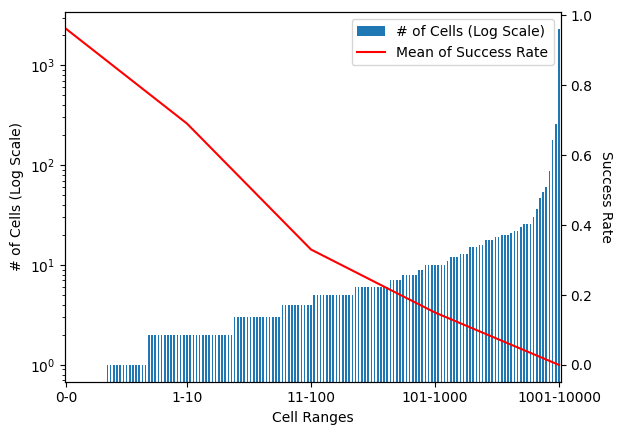

In [86]:
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages('VE_Stats/all_plot_VE_stat_v1.pdf') as pdf:
    ax = df_VE_csv[4].plot(kind='bar', xticks=[], logy=True, label="# of Cells (Log Scale)")
    ax.set_ylabel("# of Cells (Log Scale)")
    ax.set_xlabel("Cell Ranges")
    ax2 = ax.twinx()
    ax2.set_ylabel("Success Rate", rotation=270, labelpad=15)
    line_2d = ax2.plot(df_VE_stat_2_idx, df_VE_stat_2[3], color='red', label="Mean of Success Rate")
    ax2.set_xticks(df_VE_stat_2_idx, df_VE_stat_2.index.to_list())
    
    legend_handles = [ax.get_legend_handles_labels()[0][0], line_2d[0]]
    # print(legend_handles)
    ax.legend(handles=legend_handles)
    pdf.savefig()  # Save the first plot

In [84]:
df_VE_csv.to_csv("VE_Stats/plot.csv")

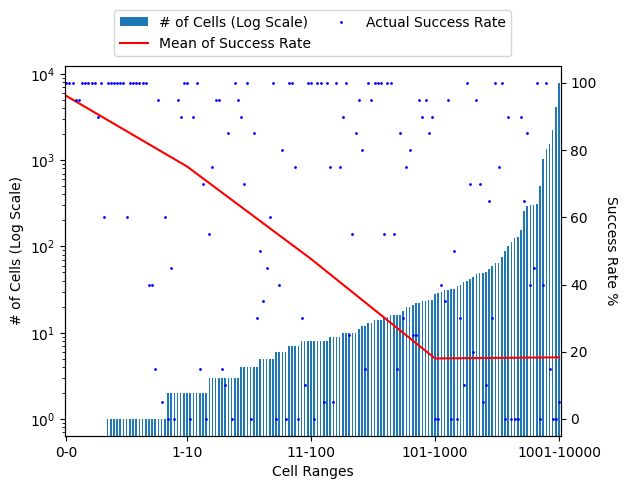

In [265]:
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages('VE_Stats/all_plot_VE_stat.pdf') as pdf:
    ax = df_VE_csv[4].plot(kind='bar', xticks=[], logy=True, label="# of Cells (Log Scale)")
    ax.set_ylabel("# of Cells (Log Scale)")
    ax.set_xlabel("Cell Ranges")
    ax2 = ax.twinx()
    ax2.set_ylabel("Success Rate %", rotation=270, labelpad=15)
    line_2d = ax2.plot(df_VE_stat_2_idx, df_VE_stat_2[3] * 100, color='red', label="Mean of Success Rate")
    ax2.set_xticks(df_VE_stat_2_idx, df_VE_stat_2.index.to_list())
    line_2d_2 = ax2.plot(range(len(df_VE_csv)), df_VE_csv[3] * 100, 'bo', label="Actual Success Rate", markersize=1)
    
    legend_handles = [ax.get_legend_handles_labels()[0][0], line_2d[0], line_2d_2[0]]
    
    ax.legend(handles=legend_handles, bbox_to_anchor=(0.1, 0.0, .8, 1.152), loc='upper center',
                      ncols=2, mode="expand", borderaxespad=0.)
    pdf.savefig()  # Save the first plot

In [214]:
df_VE_csv = df_VE_csv.sort_values(by=[3], ascending=False)
df_VE_csv

,3,4
26,1.0,5
1,1.0,0
6,1.0,0
2,1.0,0
122,1.0,76
...,...,...
112,0.0,6
132,0.0,32
81,0.0,35
138,0.0,28


[<BarContainer object of 156 artists>, <matplotlib.lines.Line2D object at 0x703071a6c0d0>]


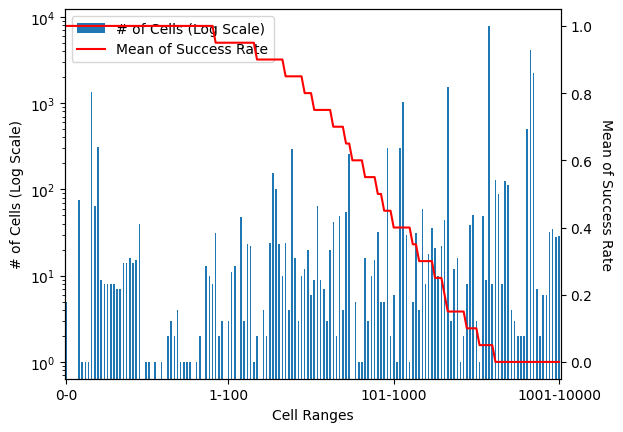

In [217]:
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages('PyranetStatisticData/all_plot_VE_stat_v2.pdf') as pdf:
    ax = df_VE_csv[4].plot(kind='bar', xticks=[], logy=True, label="# of Cells (Log Scale)")
    ax.set_ylabel("# of Cells (Log Scale)")
    ax.set_xlabel("Cell Ranges")
    ax2 = ax.twinx()
    ax2.set_ylabel("Mean of Success Rate", rotation=270, labelpad=15)
    line_2d = ax2.plot(range(len(df_VE_csv)), df_VE_csv[3], color='red', label="Mean of Success Rate")
    ax2.set_xticks(df_VE_stat_2_idx, df_VE_stat_2.index.to_list())
    
    legend_handles = [ax.get_legend_handles_labels()[0][0], line_2d[0]]
    print(legend_handles)
    ax.legend(handles=legend_handles)
    pdf.savefig()  # Save the first plot

## Old

# Explore modules synthesys

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
import subprocess
pbar = tqdm(total=len(dataset))
synth_error_ex = set()
for i in range(len(dataset)):
    example_code = dataset['code'][i]

    with open('yosys_run/top.v', 'w+') as file:
        file.write(example_code)
    runresult = subprocess.run(['./run.sh'],
                               cwd='yosys_run',
                               capture_output=True,
                               text=True
                               # stdin=subprocess.STDOUT,
                               # stderr=subprocess.STDOUT
                              )
    if runresult.returncode:
        # print(runresult.stdout)
        # print(runresult.stderr)
        # break
        synth_error_ex.add(i)
    pbar.update(1)

In [ ]:
import os
os.cpu_count()

In [5]:
import subprocess, tempfile, json, signal, os
    
def do_process(i):#process_range, synth_error_ex):
    # print(i)
    # pbar.update(1)
    # for i in process_range:
    example_code = dataset['code'][i]
    # print(example_code)
    # return
    total_num_cells = 0
    with tempfile.TemporaryDirectory() as tmpdirname:
        os.link('yosys_run/run.sh', f'{tmpdirname}/run.sh')
        with open(f'{tmpdirname}/top.v', 'w+') as file:
            file.write(example_code)
        try:
            runresult = subprocess.Popen('./run.sh',
                                         cwd=tmpdirname,
                                        stdout=subprocess.DEVNULL,
                                         stderr=subprocess.DEVNULL,
                                           shell=True, 
                                         preexec_fn=os.setsid)
            # runresult = subprocess.Popen('./run.sh',
            #                             # ['./run.sh'], 
            #                              cwd=tmpdirname,
            #                              shell=True,
            #                             stdout=subprocess.DEVNULL,
            #                              stderr=subprocess.DEVNULL)
            runresult.wait(40)
            if runresult.returncode != 0:
                return (i, 0, None)
            else:
                with open(f'{tmpdirname}/out.json', 'r') as file:
                    module_synthesis = json.load(file)
                    for module in module_synthesis['modules']:
                        total_num_cells += module_synthesis['modules'][module]['num_cells']
                    
                return (i, 0, total_num_cells)
        except subprocess.TimeoutExpired:
            os.killpg(os.getpgid(runresult.pid), signal.SIGTERM)
            return (i, 1, None)
            
        # synth_error_ex.add(i)
    # pbar.update(1)

In [6]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool

import os
num_core = os.cpu_count() - 4
my_range = range(len(dataset))

synth_error_ex = set()
synth_timeout_ex = set()
all_total_num_cells = [None] * (my_range[-1] + 1)
with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        ii, timeout, total_num_cells = i
        if timeout:
            synth_timeout_ex.add(ii)
        elif total_num_cells != None:
            all_total_num_cells[ii] = total_num_cells
        else:
            synth_error_ex.add(ii)
# print(all_total_num_cells)

  0%|          | 0/661318 [00:00<?, ?it/s]

In [7]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'r') as file:
    all_total_num_cells = json.load(file)

In [ ]:
all_total_num_cells

In [7]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'w+') as file:
    json.dump(all_total_num_cells, file)

In [16]:
import numpy as np
all_num_cells_with_error = np.full((len(all_total_num_cells), 2), None)
all_num_cells_with_error

array([[None, None],
       [None, None],
       [None, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(661318, 2), dtype=object)

In [17]:
all_num_cells_with_error[:,0] = all_total_num_cells
all_num_cells_with_error

array([[0, None],
       [2, None],
       [16, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(661318, 2), dtype=object)

In [22]:
all_num_cells_with_error[list(synth_timeout_ex),1] = 2
all_num_cells_with_error

array([[0, None],
       [2, None],
       [16, None],
       ...,
       [None, 1],
       [None, 1],
       [None, 1]], shape=(661318, 2), dtype=object)

In [24]:
str(all_num_cells_with_error[0])

'[0 None]'

In [9]:
dataset = dataset.add_column("synth_status", all_total_num_cells)

In [10]:
dataset.to_json('PyranetStatisticData/dataset_all_with_cell_num_error.jsonl')

Creating json from Arrow format:   0%|          | 0/662 [00:00<?, ?ba/s]

2526200679

In [ ]:
(np.min(all_num_cells_with_error[:,0]), np.max(all_num_cells_with_error[:,0]))

In [33]:
# all_valid_num_cells = np.where(all_num_cells_with_error[:,0] != None, all_num_cells_with_error[:,0], all_num_cells_with_error[:,0])
# all_valid_num_cells
all_valid_num_cells = np.where(all_num_cells_with_error[:,0] != None)

In [36]:
all_valid_num_cells = all_num_cells_with_error[all_valid_num_cells,0]
all_valid_num_cells

array([[0, 2, 16, ..., 322, 3, 0]], shape=(1, 351429), dtype=object)

In [37]:
np.max(all_valid_num_cells)

217596

In [77]:
max([i for i in all_total_num_cells if i != None])

108837

In [ ]:
pbar = tqdm(total=len(dataset))
# synth_error_ex = set()
for i in range(len(dataset)):
    ret_val = do_process(i)
    # if ret_val != None:
    #     synth_error_ex.add(i)
    pbar.update(1)
pbar.close()
# 1283

In [ ]:
print(dataset['code'][897])

In [ ]:
pbar.close()

In [ ]:
from multiprocessing import Process
import os
num_core = os.cpu_count() - 1
processes = [None] * num_core
process_ranges = range(len(dataset))
range_slice_step = int(len(process_ranges) / num_core) + 1
for i in range(num_core):
    range_slice_start = range_slice_step * i
    # if i == num_core - 1:
    #     range_slice_end = None
    # else:
    range_slice_end = range_slice_start + 1 #range_slice_step - 1
    cur_range = process_ranges[range_slice_start:range_slice_end]
    # print(cur_range)
    processes[i] = Process(target=do_process, args=(cur_range, synth_error_ex))
    processes[i].start()
for i in range(num_core):
    processes[i].join()

In [ ]:
pbar.close()

In [ ]:
runresult.stdout

In [ ]:
i

# Explore Logic Numbers

In [ ]:
dataset['synth_status'].filter(lambda x: print(x))

In [4]:
import numpy as np

all_cell_num_with_no_null = np.array(dataset['synth_status'])
all_cell_num_with_no_null

array([0.0, 2.0, 16.0, ..., None, None, None],
      shape=(661318,), dtype=object)

In [5]:
all_cell_num_with_no_null_idx = np.where(all_cell_num_with_no_null != None)
all_cell_num_with_no_null_idx

(array([     0,      1,      2, ..., 661292, 661309, 661311],
       shape=(351429,)),)

In [6]:
all_cell_num_with_no_null = all_cell_num_with_no_null[all_cell_num_with_no_null_idx]
all_cell_num_with_no_null

array([0.0, 2.0, 16.0, ..., 322.0, 3.0, 0.0],
      shape=(351429,), dtype=object)

In [7]:
all_cell_num_with_no_null = all_cell_num_with_no_null.astype(np.uint64) 
all_cell_num_with_no_null

array([  0,   2,  16, ..., 322,   3,   0], shape=(351429,), dtype=uint64)

In [8]:
np.max(all_cell_num_with_no_null)

np.uint64(217596)

## All Logic num

In [ ]:
set(all_cell_num_with_no_null)

In [28]:
len(np.where(all_cell_num_with_no_null == 0)[0])

42468

In [138]:
all_cell_num_with_no_null

array([  0,   2,  16, ..., 322,   3,   0], shape=(351429,), dtype=uint64)

In [9]:
logic_num_group = {str(logic_num): len(np.where(all_cell_num_with_no_null == logic_num)[0]) for logic_num in set(all_cell_num_with_no_null)}
len(logic_num_group)

12169

In [12]:
logic_num_group = {'num_cell': logic_num_group.keys(),
                  'num_module': [logic_num_group[key] for key in logic_num_group]}
logic_num_group

{'num_cell': dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '

In [13]:
list(logic_num_group.keys())[:100]

['num_cell', 'num_module']

In [22]:
logic_num_group['num_cell'] = list(logic_num_group['num_cell'])

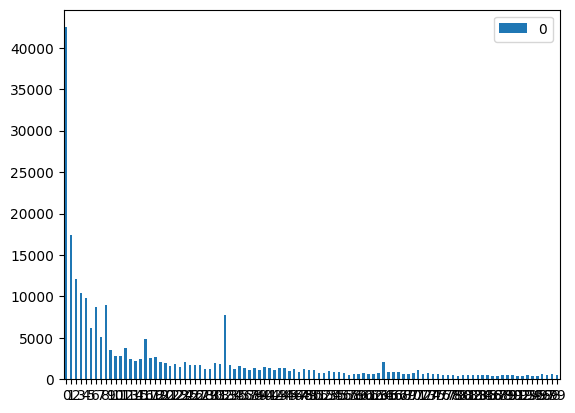

In [18]:
import pandas as pd
logic_num_group_0 = {'num_cell': logic_num_group['num_cell'][:100],
                  'num_module': logic_num_group['num_module'][:100]}
df = pd.DataFrame(logic_num_group_0['num_module'], index=logic_num_group_0['num_cell'])
# ax = df.plot.bar(x='num_cell', y='num_module', rot=0)
ax = df.plot.bar(rot=0)

In [19]:
def num_cell_segment(x):
    int_x = int(x)
    group = ''
    if x == 0:
        group = '0-0'
    else:
        for i in range(1,92, 10):
            cur_range = (i, i + 9)
            if cur_range[0] <= int_x <= cur_range[1]:
                group = f'{cur_range[0]}-{cur_range[1]}'
                break
    # print(x)
    return group
        
df_group = df.groupby(num_cell_segment, ).sum() #.rename(columns={0: 'Number of Cells'}).ren.plot.bar(rot=45,)

In [20]:
df_group = df_group.rename(index={'': '0'}).rename(columns={0: 'Number of Modules'})
df_group

,Number of Cells
0,42468
1-10,85218
11-20,27726
21-30,16752
31-40,20756
41-50,11568
51-60,7505
61-70,8587
71-80,6418
81-90,4737


In [39]:
plt.savefig('PyranetStatisticData/first_plot.pdf', format='pdf')
plt.close()

In [41]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages('PyranetStatisticData/first_plot.pdf') as pdf:
    plt.figure()
    # plt.bar(df_group.index, df_group['Number of Cells'])
    df_group.plot.bar(rot=45, )
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory


<Figure size 640x480 with 0 Axes>

## Plot all

In [44]:
# matplotlib.pyplot.subplot_mosaic
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt_subplot_mosaic = [[0, 1],
                     [2,3],
                     [4,4]]
plt.figure()
plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')
with PdfPages('PyranetStatisticData/all_plot_2.pdf') as pdf:
    # plt.bar(df_group.index, df_group['Number of Cells'])
    # df_group.plot.bar(rot=45, )
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory

<Figure size 640x480 with 0 Axes>

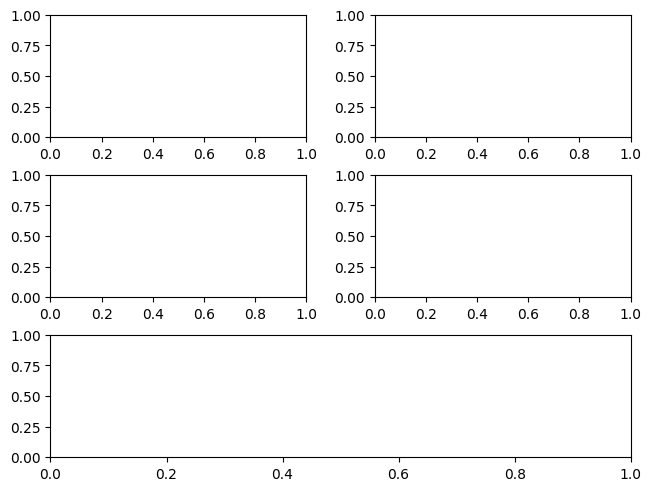

In [45]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt_subplot_mosaic = [[0, 1],
                     [2,3],
                     [4,4]]

fig, axd = plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')

In [50]:
dataset['synth_status'][300000]

111.0

In [15]:
second_index = np.array([None] * len(logic_num_group['num_cell']))

## Range 0 - 100

In [ ]:
logic_num_group

In [19]:
logic_num_group_np = np.array(logic_num_group['num_cell'])
second_index = np.array(second_index)
second_index

array([None, None, None, ..., None, None, None],
      shape=(12169,), dtype=object)

In [18]:
logic_num_group_np = logic_num_group_np.astype(np.uint64)
logic_num_group_np

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'dict_keys'

In [66]:
idx_s = np.where(logic_num_group_np == 0)[0]
second_index[idx_s] = '0-0'
second_index

array(['0-0', None, None, ..., None, None, None],
      shape=(12169,), dtype=object)

In [74]:
# idx_s = np.where(1 <= logic_num_group_np)[0]# and np.where(logic_num_group_np <= 10)[0]
# # second_index[idx_s] = '0-0'
# # second_index[idx_s]
# idx_s

array([    1,     2,     3, ..., 12166, 12167, 12168], shape=(12168,))

In [ ]:
logic_num_group['num_cell']

In [80]:
len(second_index)

12169

In [21]:
logic_num_group

{'num_cell': dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '

In [27]:
for i in range(len(second_index)):
    int_x = int(logic_num_group['num_cell'][i])
    if int_x == 0:
        second_index[i] = '0-0'
    else:
        # 1-100, 
        # 101-1000
        # 1001-10000
        # 10001-100000
        # 100001-25000

        start_i = 100001
        stop_i = 220000
        step_i = 10000
        for ii in range(start_i,stop_i, step_i):
            cur_range = (ii, ii + step_i - 1)
            if cur_range[0] <= int_x <= cur_range[1]:
                second_index[i] = f'{cur_range[0]}-{cur_range[1]}'
                break
        # print(cur_range)
second_index

array(['0-0', '1-10', '1-10', ..., '30001-40000', '30001-40000',
       '30001-40000'], shape=(12169,), dtype=object)

In [28]:
len(np.where(second_index == None)[0])

0

In [29]:
import json
with open('PyranetStatisticData/second_index.json', 'w+') as file:
    json.dump(second_index.tolist(), file)
    # second_index.tofile()

## Multi-index

In [30]:
import pandas as pd
tuples = list(zip(*[second_index.tolist(), logic_num_group['num_cell']]))
# multi_index = pd.MultiIndex(tuples, names=["first", "second"])
# multi_index

In [31]:
multi_index = pd.MultiIndex.from_tuples(tuples, names=["Number of Cells", "second"])

In [32]:
df_2 = pd.DataFrame(logic_num_group['num_module'], index=multi_index)

In [33]:
second_index

array(['0-0', '1-10', '1-10', ..., '30001-40000', '30001-40000',
       '30001-40000'], shape=(12169,), dtype=object)

In [34]:
df_2 = df_2.rename(columns={0: 'Number of Modules'})
df_2

Number of Modules
Number of Cells second                   
0-0             0                   42468
1-10            1                   17462
                2                   12093
                3                   10438
                4                    9762
...                                   ...
30001-40000     32676                   1
60001-70000     65459                   1
30001-40000     32728                   1
                32735                   1
                32756                   1

[12169 rows x 1 columns]

## Plot all with multi index

In [186]:
df_test = pd.DataFrame({"a": [1, 2, 3, 4]}, index=['A', 'C', 'b', 'd'])
df_test.sort_index(key=lambda x: x.str.lower())

,a
A,1
b,3
C,2
d,4


In [35]:
def df_2_sort(x: pd.Index):
    # print(x.str.split('-').map(lambda y: int(y[0])))
    return x.str.split('-').map(lambda y: int(y[0]))
#     # return x[0].split('-')[0]
df_2_sorted = df_2.sort_index(key=df_2_sort)

In [36]:
df_2_sorted

Number of Modules
Number of Cells second                   
0-0             0                   42468
1-10            1                   17462
                2                   12093
                3                   10438
                4                    9762
...                                   ...
210001-220000   213045                  1
                216445                  1
                216495                  1
                217556                  1
                217596                  1

[12169 rows x 1 columns]

In [37]:
df_2_sorted.index

MultiIndex([(          '0-0',      '0'),
            (         '1-10',      '1'),
            (         '1-10',      '2'),
            (         '1-10',      '3'),
            (         '1-10',      '4'),
            (         '1-10',      '5'),
            (         '1-10',      '6'),
            (         '1-10',      '7'),
            (         '1-10',      '8'),
            (         '1-10',      '9'),
            ...
            ('170001-180000', '177359'),
            ('170001-180000', '177486'),
            ('180001-190000', '187604'),
            ('190001-200000', '192420'),
            ('200001-210000', '204706'),
            ('210001-220000', '213045'),
            ('210001-220000', '216445'),
            ('210001-220000', '216495'),
            ('210001-220000', '217556'),
            ('210001-220000', '217596')],
           names=['Number of Cells', 'second'], length=12169)

In [38]:
df_2_sorted_group = df_2_sorted.groupby(level=0).sum()

In [39]:
df_2_sorted_group

,Number of Modules
Number of Cells,
0-0,42468
1-10,85218
100001-110000,641
10001-20000,2879
1001-2000,9508
101-200,34621
11-20,27726
110001-120000,158
120001-130000,20


In [40]:
df_2_sorted_group_sorted = df_2_sorted_group.sort_index(key=lambda x: x.str.split('-').map(lambda y: int(y[0])))
df_2_sorted_group_sorted

,Number of Modules
Number of Cells,
0-0,42468
1-10,85218
11-20,27726
21-30,16752
31-40,20756
41-50,11568
51-60,7505
61-70,8587
71-80,6418


In [ ]:
df_2_sorted_group_sorted = df_2_sorted_group_sorted.rename_axis(index={'first': 'Number of Cells'})
df_2_sorted_group_sorted

In [137]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pandas.plotting import table

plt_subplot_mosaic = [[0, 0],
                     [1,2],
                     [3,4]]
plt.figure()
fig, axd = plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')

df_ranges = [('0-0', '91-100'), 
             ('101-200', '901-1000'), 
             ('1001-2000', '9001-10000'),
             ('10001-20000', '90001-100000'),
             ('100001-110000', None),
            ]
with PdfPages('PyranetStatisticData/all_plot_final_1.pdf') as pdf:
    
    for i in range(len(df_ranges)):
        df_range = df_ranges[i]
        df_plot: pd.DataFrame = df_2_sorted_group_sorted.loc[df_range[0]:df_range[1]]
        df_plot = df_plot.astype(np.uint64)
        
        #
        
        rot = 22.5

        df_plot_total = pd.DataFrame(df_plot.sum()).rename(index={'Number of Modules': 'total'}, columns={0: 'Number of Modules'})
        df_plot_statistic = df_plot.describe().loc[['min', 'max']]
        
        
        df_plot_statistic = pd.concat([df_plot_statistic, df_plot_total]).astype(np.uint64)
        
        colWidths = [1/4, 1/4] if i == 0 else [1/2, 1/2]
        df_plot.plot.bar(rot=rot, ax=axd[i], figsize=(10, 10), legend=None)
        print(df_plot_statistic)
        cur_table = table(axd[i], df_plot_statistic, loc="upper right", colWidths=colWidths)
        
        
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory
# 

       Number of Modules
min                 4737
max                85218
total             236560
       Number of Modules
min                 1626
max                34621
total              81336
       Number of Modules
min                  642
max                 9508
total              26302
       Number of Modules
min                   36
max                 2879
total               6328
       Number of Modules
min                    1
max                  641
total                903


<Figure size 640x480 with 0 Axes>

In [118]:
[1, 2, 3] * 2

[1, 2, 3, 1, 2, 3]

# Explore instantiation number

min_ins_num = [len(dataset['module_definition'][0]), 0]
max_ins_num = [len(dataset['module_definition'][0]), 0]
len_dict = {}
for i in range(1, len(dataset)):
    len_module_definition = len(dataset['module_definition'][i])
    if len_module_definition < min_ins_num[0]:
        min_ins_num[0] = len_module_definition
    if len_module_definition > max_ins_num[0]:
        max_ins_num[0] = len_module_definition

    len_module_definition = str(len_module_definition)
    if len_module_definition not in len_dict:
        len_dict[len_module_definition] = []
    len_dict[len_module_definition].append(i)
    
(min_ins_num, max_ins_num)

In [ ]:
len(len_dict)

In [ ]:
lens = [int(x) for x in list(len_dict.keys())]

In [ ]:
lens.sort()
lens

In [ ]:
import json
with open('PyranetStatisticData/num_ins_dictionary.json', 'w+') as file:
    json.dump(len_dict, file)


In [ ]:
print(dataset['code'][111111])

In [ ]:
print(dataset['code'][4304])

In [ ]:
len_dict['2'][10]

## Bar charts

In [ ]:
!pip install pandas matplotlib

In [ ]:
import pandas as pd

In [ ]:
ins_num = [int(x) for x in list(len_dict.keys())]
ins_num.sort()
module_num = [len(len_dict[str(x)]) for x in ins_num]

In [ ]:
len_dict['1'][10]

In [ ]:
len(len_dict)

In [ ]:
# ins_num = [int(x) for x in list(len_dict.keys())]
# ins_num.sort()
# module_num = [len_dict[str(x)] for x in ins_num]
a_df = pd.DataFrame({'ins_num': ins_num, 'module_num': module_num})
ax = a_df[:10].plot.bar(x='ins_num', y='module_num', rot=0)

In [ ]:
len(len_dict)

In [ ]:
a_df['module_num']

In [ ]:
ax2 = a_df[2:].plot.bar(x='ins_num', y='module_num', rot=0)